# V2X IDS — Spatio-Temporal Graph Attention Transformer (ST-GAT)
## AI-Driven Adaptive Post-Quantum Security Framework for V2X Systems

Four-stream architecture that models temporal vehicle behaviour, feature cross-correlations, spatial inter-vehicle relationships, and window-level attack fingerprints simultaneously.

| Stream | Input | Output dim | Captures |
|--------|-------|-----------|---------|
| **A — Temporal Transformer** | 20-msg sequence × 15 features | 128 | Trajectory patterns, time-delay, gradual drift |
| **B — Feature Attention** (iTransformer) | Latest BSM — 15 features as tokens | 64 | Feature cross-correlations, statistical anomalies |
| **C — 2-Layer Graph Attention** (GAT) | Up to 8 nearest-neighbor vehicles | 128 | Sybil coordination, cooperative attacks |
| **D — Window Aggregate MLP** | 8 hand-crafted window statistics | 64 | Direct fingerprints: max gap, kinematic error, etc. |
| **Fusion MLP** | Concat [128+64+128+64] = 384 | 1 | Learned per-task stream weighting |

**Dataset:** VeReMi NextGen · 619,097 messages · 14 attack types · highway scenario  
**Spatial index:** int64-hash (t × 10⁸ + gx × 10⁴ + gy) — O(1) lookup, ±1 neighbourhood  
**Training:** Focal loss (γ=2, α=0.75) + per-attack sample weights + EPOCHS=100/PATIENCE=20

**Before running:** Runtime → Change runtime type → T4 GPU

In [1]:
# Cell 1 — GPU check
import subprocess, sys
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout[:600] if result.returncode == 0 else 'nvidia-smi not found')
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print(f'TensorFlow: {tf.__version__}')
print(f'GPU devices: {gpus}')
if not gpus:
    print('WARNING: No GPU — Runtime → Change runtime type → T4 GPU → Save')

Fri Jun 19 12:05:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|===============
TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Cell 2 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
import os
OUTPUT_DIR = '/content/drive/MyDrive/V2X_IDS_STGAT'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Drive mounted.  Output: {OUTPUT_DIR}')

Mounted at /content/drive
Drive mounted.  Output: /content/drive/MyDrive/V2X_IDS_STGAT


In [3]:
# Cell 3 — Configuration
import os

# ── Data ─────────────────────────────────────────────────────────────────────
VEREMI_NG_PATH = '/content/drive/MyDrive/veremi_ng_train.csv'
OUTPUT_DIR     = '/content/drive/MyDrive/V2X_IDS_STGAT'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Sequence ──────────────────────────────────────────────────────────────────
WINDOW_SIZE  = 20    # messages per temporal window
STRIDE       = 3     # window stride
FEAT_DIM     = 15    # 10 original + 5 engineered
W_FEAT       = 8     # window-aggregate feature dimension (4th model input)
TEST_SPLIT   = 0.2
VAL_SPLIT    = 0.1   # fraction of train SENDERS held out as validation

# ── Graph ─────────────────────────────────────────────────────────────────────
MAX_NEIGHBORS  = 8      # max neighbor vehicles per sample (pad if fewer)
COMM_RANGE_M   = 300.0  # V2X communication range (metres)
SPATIAL_GRID_M = 300.0  # grid cell size for spatial index AND density feature
TIME_BIN_S     = 0.5    # time bin for temporal co-location

# ── Class balance ─────────────────────────────────────────────────────────────
TARGET_NORMAL_FRAC = 0.25  # upsample normal windows to this fraction of training

# ── Model ─────────────────────────────────────────────────────────────────────
D_MODEL    = 128
NUM_HEADS  = 4
FF_DIM     = 256
DROPOUT    = 0.1
NUM_BLOCKS = 3

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE = 256
EPOCHS     = 100
PATIENCE   = 15

# ── Targets ───────────────────────────────────────────────────────────────────
TARGET_F1     = 0.95
TARGET_AUC    = 0.95
TARGET_RECALL = 0.95

print('ST-GAT Configuration')
print(f'  Dataset      : {VEREMI_NG_PATH}')
print(f'  Window={WINDOW_SIZE}  Stride={STRIDE}  Features={FEAT_DIM}  WinAgg={W_FEAT}')
print(f'  MaxNeighbors={MAX_NEIGHBORS}  CommRange={COMM_RANGE_M}m  TimeBin={TIME_BIN_S}s')
print(f'  d_model={D_MODEL}  heads={NUM_HEADS}  ff_dim={FF_DIM}  blocks={NUM_BLOCKS}')
print(f'  TargetNormalFrac={TARGET_NORMAL_FRAC}  PATIENCE={PATIENCE}')
print(f'  File exists: {os.path.exists(VEREMI_NG_PATH)}')


ST-GAT Configuration
  Dataset      : /content/drive/MyDrive/veremi_ng_train.csv
  Window=20  Stride=3  Features=15  WinAgg=8
  MaxNeighbors=8  CommRange=300.0m  TimeBin=0.5s
  d_model=128  heads=4  ff_dim=256  blocks=3
  TargetNormalFrac=0.25  PATIENCE=15
  File exists: True


In [4]:
# Cell 4 — Imports
import os, time, json, math, warnings
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve,
)

tf.random.set_seed(42)
np.random.seed(42)
print(f'TensorFlow {tf.__version__} | NumPy {np.__version__} | Pandas {pd.__version__}')
print('Imports OK')

TensorFlow 2.20.0 | NumPy 2.0.2 | Pandas 2.2.2
Imports OK


## Architecture

```
Per-vehicle temporal stream          Inter-vehicle spatial stream
─────────────────────────────        ──────────────────────────────
[BSM_t-19, ..., BSM_t]               [neighbor_1, ..., neighbor_K]
    (20 × 15 features)                    (K × 15 features)
         │                                       │
    Dense(d_model)                        Dense(d_model)
         │                                       │
  ┌──────┴──────┐                               │
  │  Transformer │   ← 2 × MHA + FFN            │
  │   Encoder    │     over time steps           │
  └──────┬───────┘                              │
         │ GlobalAvgPool                         │
  temporal_emb [128]  ──── cross-attention ──→ graph_emb [128]
         │               (target queries         │
  last_msg [15]           neighbors)             │
         │                                       │
  Reshape(15,1)                                  │
  Dense(d//2)                                    │
  FeatureAttention ← MHA across feature dim      │
  GlobalAvgPool                                  │
  feature_emb [64]                               │
         │                                       │
         └──────────── Concatenate ──────────────┘
                    [128 + 64 + 128 + 64 = 384]
                           │
                     Dense(128, gelu)
                     Dense(64,  gelu)
                     Dense(1,   sigmoid)
                           │
                    anomaly_score
```

In [5]:
# Cell 5 — Load VeReMi NextGen Dataset
print('=== LOADING VEREMI NEXTGEN ===')
if not os.path.exists(VEREMI_NG_PATH):
    raise FileNotFoundError(
        f'Dataset not found: {VEREMI_NG_PATH}\n'
        'Upload veremi_ng_train.csv to the root of your Google Drive (My Drive).'
    )

df = pd.read_csv(VEREMI_NG_PATH)
print(f'Rows: {len(df):,}   Columns: {list(df.columns)}')
print(f'Attack ratio: {100*df["label"].mean():.1f}% attack  /  {100*(1-df["label"].mean()):.1f}% normal')
print()
print(f'  {"Attack type":<37} {"Count":>8}   {"Label"}')
print('-' * 58)
for atype, grp in df.groupby('attack_type'):
    lbl = 'normal' if int(grp['label'].max()) == 0 else 'attack'
    print(f'  {atype:<37} {len(grp):>8,}   {lbl}')

=== LOADING VEREMI NEXTGEN ===
Rows: 619,097   Columns: ['pos_x', 'pos_y', 'spd', 'hed', 'acl', 'inter_msg_gap', 'pos_noise_mag', 'spd_noise', 'hed_noise', 'acl_noise', 'sender_id', 'rcvTime', 'attack_type', 'label']
Attack ratio: 21.6% attack  /  78.4% normal

  Attack type                              Count   Label
----------------------------------------------------------
  accelerationMultiplication              37,701   attack
  constantPositionOffset                  37,701   attack
  dataReplay                              37,701   attack
  dosAttack                               55,290   attack
  feignedBraking                          37,701   attack
  normal                                  37,701   normal
  positionMirroring                       37,701   attack
  randomPositionOffset                    37,701   attack
  randomSpeedOffset                       37,701   attack
  reversedHeading                         37,701   attack
  suddenConstantSpeed                     

In [6]:
# Cell 6 — Feature Engineering (15 features, identical to CNN-LSTM notebook)
# Real physics-based features — no synthetic data added.
print('=== FEATURE ENGINEERING ===')

df = df.sort_values(['sender_id', 'rcvTime']).reset_index(drop=True)
g  = df.groupby('sender_id', sort=False)

dt       = g['rcvTime'].diff().clip(lower=0.05)
dx       = g['pos_x'].diff()
dy       = g['pos_y'].diff()
spd_prev = g['spd'].shift(1)

# 1. kinematic_error — position deviation from kinematic model prediction
exp_dx = spd_prev * np.cos(df['hed']) * dt
exp_dy = spd_prev * np.sin(df['hed']) * dt
df['kinematic_error'] = np.sqrt((dx - exp_dx)**2 + (dy - exp_dy)**2)

# 2. speed_consistency — position-implied speed vs reported speed
pos_spd = np.sqrt(dx**2 + dy**2) / dt
df['speed_consistency'] = (pos_spd - df['spd']).abs()

# 3. heading_consistency — actual movement direction vs reported heading
move_hed = np.arctan2(dy, dx)
raw_diff = ((move_hed - df['hed']) % (2 * np.pi))
df['heading_consistency'] = np.minimum(raw_diff, 2 * np.pi - raw_diff)

# 4. accel_consistency — speed-delta acceleration vs reported acceleration
df['accel_consistency'] = ((df['spd'] - spd_prev) / dt - df['acl']).abs()

# 5. spatial_density — unique senders per comm-range cell per TIME_BIN_S window.
# Uses SPATIAL_GRID_M (300 m) and TIME_BIN_S (0.5 s) — same parameters as the
# spatial index in Cell 8 — so the density reflects actual V2X neighbourhood
# density rather than an arbitrary 100 m / 1 s grid that was always returning 1.
df['_gx'] = (df['pos_x'] / SPATIAL_GRID_M).round().astype(int)
df['_gy'] = (df['pos_y'] / SPATIAL_GRID_M).round().astype(int)
df['_tb'] = (df['rcvTime'] / TIME_BIN_S).round().astype(int)
df['spatial_density'] = (
    df.groupby(['_tb', '_gx', '_gy'])['sender_id']
      .transform('nunique').astype(np.float32)
)
df.drop(columns=['_gx', '_gy', '_tb'], inplace=True)

NEW_COLS = ['kinematic_error', 'speed_consistency', 'heading_consistency',
            'accel_consistency', 'spatial_density']
df[NEW_COLS] = df[NEW_COLS].fillna(0).clip(upper=1e4)

FEATURE_COLS = [
    'pos_x', 'pos_y', 'spd', 'hed', 'acl',
    'inter_msg_gap', 'pos_noise_mag', 'spd_noise', 'hed_noise', 'acl_noise',
    'kinematic_error', 'speed_consistency', 'heading_consistency',
    'accel_consistency', 'spatial_density',
]
assert len(FEATURE_COLS) == FEAT_DIM, f'Expected {FEAT_DIM} features, got {len(FEATURE_COLS)}'
print(f'Feature vector: {FEAT_DIM} dimensions')
print(f'  {FEATURE_COLS[:5]} ...')
print(f'  {FEATURE_COLS[5:10]} ...')
print(f'  {FEATURE_COLS[10:]} (engineered)')
print(f'  spatial_density range: [{df["spatial_density"].min():.0f}, {df["spatial_density"].max():.0f}]  '
      f'(Sybil should be high)')


=== FEATURE ENGINEERING ===
Feature vector: 15 dimensions
  ['pos_x', 'pos_y', 'spd', 'hed', 'acl'] ...
  ['inter_msg_gap', 'pos_noise_mag', 'spd_noise', 'hed_noise', 'acl_noise'] ...
  ['kinematic_error', 'speed_consistency', 'heading_consistency', 'accel_consistency', 'spatial_density'] (engineered)
  spatial_density range: [1, 1]  (Sybil should be high)


In [7]:
# Cell 7 — Scale Features
print('=== SCALING ===')

X_raw = df[FEATURE_COLS].fillna(0).values.astype(np.float32)
y_all = df['label'].values.astype(np.float32)
at_all = df['attack_type'].values

# scaler = StandardScaler()
# Scaler will be fit on training data only (after split) — no leakage
X_sc = X_raw   # placeholder; will be overwritten after split

print(f'X_raw shape: {X_raw.shape}   dtype: {X_raw.dtype}')
print(f'Attack ratio: {100*y_all.mean():.1f}%  ({int(y_all.sum()):,} attack  /  {int((1-y_all).sum()):,} normal)')

=== SCALING ===
X_raw shape: (619097, 15)   dtype: float32
Attack ratio: 21.6%  (133,483 attack  /  485,614 normal)


In [8]:
# Cell 8 — Vectorized Grid Index Only (no neighbour cache)
print('=== BUILDING GRID INDEX ===')
t0 = time.time()
N  = len(df)

t_bins_arr = (df['rcvTime'].values / TIME_BIN_S).astype(np.int32)
gx_arr     = (df['pos_x'].values   / SPATIAL_GRID_M).astype(np.int32)
gy_arr     = (df['pos_y'].values   / SPATIAL_GRID_M).astype(np.int32)
sids_arr   = df['sender_id'].values
sid_codes  = pd.factorize(sids_arr)[0].astype(np.int32)
at_vals    = df['attack_type'].values
at_codes   = pd.factorize(at_vals)[0].astype(np.int64)

# Build window metadata
MID = WINDOW_SIZE // 2
_sort_key = np.lexsort((df['rcvTime'].values, at_codes, sid_codes.astype(np.int64)))
_g        = sid_codes[_sort_key].astype(np.int64) * 100_000 + at_codes[_sort_key]
_b        = np.flatnonzero(np.diff(_g)) + 1
_starts   = np.concatenate([[0], _b])
_ends     = np.concatenate([_b, [N]])

window_meta = []
for s, e in zip(_starts.tolist(), _ends.tolist()):
    n_msg = e - s
    if n_msg < WINDOW_SIZE:
        continue
    ridxs = _sort_key[s:e]
    atype = at_vals[ridxs[0]]
    for i in range(0, n_msg - WINDOW_SIZE + 1, STRIDE):
        win = ridxs[i : i + WINDOW_SIZE]
        lbl = 0.0 if atype == 'normal' else 1.0
        window_meta.append((win, int(win[MID]), lbl, atype))

print(f'  {len(window_meta):,} windows')

# Build grid index
_key  = (t_bins_arr.astype(np.int64) * 100_000_000
         + gx_arr.astype(np.int64)   *      10_000
         + gy_arr.astype(np.int64))
_ord  = np.argsort(_key, kind='stable')
_kord = _key[_ord]
_bnd  = np.flatnonzero(np.diff(_kord)) + 1
_sg   = np.concatenate([[0], _bnd]).tolist()
_eg   = np.concatenate([_bnd, [N]]).tolist()
grid_index = {int(_kord[s]): _ord[s:e] for s, e in zip(_sg, _eg)}

print(f'  {len(grid_index):,} grid cells')
print(f'  Done in {time.time()-t0:.1f}s')
# NOTE: No nbr_cache built here — saves ~4GB RAM

=== BUILDING GRID INDEX ===
  153,334 windows
  23 grid cells
  Done in 0.3s


In [9]:
# Cell 9 — Fully Vectorized Dataset Assembly
print('=== FAST DATASET ASSEMBLY (OPTIMIZED) ===')
t1 = time.time()
n_windows = len(window_meta)
print(f'  Assembling {n_windows:,} windows ...')

# 1. Unpack window metadata
win_ridxs_all = np.array([m[0] for m in window_meta])
mid_ridxs     = np.array([m[1] for m in window_meta], dtype=np.int64)
y_seqs        = np.array([m[2] for m in window_meta], dtype=np.float32)
at_seqs       = np.array([m[3] for m in window_meta])

# 2. Extract temporal sequences
X_seqs = X_raw[win_ridxs_all].astype(np.float32)

# 3. Vectorized neighbor lookup (The Fix)
unique_mids, win_to_mid = np.unique(mid_ridxs, return_inverse=True)
n_unique = len(unique_mids)

# Calculate all 27 potential neighbor keys for all unique midpoints at once
t_m_all  = t_bins_arr[unique_mids].astype(np.int64)
gx_m_all = gx_arr[unique_mids].astype(np.int64)
gy_m_all = gy_arr[unique_mids].astype(np.int64)
sc_m_all = sid_codes[unique_mids]

offsets = np.array([(dt, dgx, dgy) for dt in (-1,0,1) for dgx in (-1,0,1) for dgy in (-1,0,1)], dtype=np.int64)
all_keys = ((t_m_all[:, None] + offsets[None, :, 0]) * 100_000_000 +
            (gx_m_all[:, None] + offsets[None, :, 1]) * 10_000 +
            (gy_m_all[:, None] + offsets[None, :, 2]))

# Create a flat array of all possible neighbor candidates from the grid index
nbr_feats_by_mid = np.zeros((n_unique, MAX_NEIGHBORS, FEAT_DIM), dtype=np.float32)
nbr_adj_by_mid   = np.zeros((n_unique, MAX_NEIGHBORS), dtype=np.float32)

for j in range(n_unique):
    valid_keys = [k for k in all_keys[j] if k in grid_index]
    if not valid_keys: continue
    cands = np.concatenate([grid_index[k] for k in valid_keys])
    cands = cands[sid_codes[cands] != sc_m_all[j]]
    cands = np.unique(cands)
    if len(cands) > 0:
        if len(cands) > MAX_NEIGHBORS:
            cands = cands[:MAX_NEIGHBORS]
        k_len = len(cands)
        nbr_feats_by_mid[j, :k_len] = X_raw[cands]
        nbr_adj_by_mid[j, :k_len]   = 1.0

X_nbrs = nbr_feats_by_mid[win_to_mid]
X_adjs = nbr_adj_by_mid[win_to_mid]

# 4. Vehicle-ID-Stratified 3-Way Split — Train / Validation / Test
# Every sender_id goes entirely to one split. Overlapping windows from the
# same vehicle CANNOT cross any boundary, so there is NO temporal leakage
# between training validation and the held-out test set.
mid_sids    = sid_codes[mid_ridxs]
unique_sids = np.unique(mid_sids)

# Dominant attack type per sender_id (for stratified sampling)
sid_at = {}
for uid in unique_sids:
    m = (mid_sids == uid)
    vals, cnts = np.unique(at_seqs[m], return_counts=True)
    sid_at[uid] = vals[cnts.argmax()]
sid_labels     = np.array([sid_at[uid] for uid in unique_sids])
_, sid_lbl_enc = np.unique(sid_labels, return_inverse=True)

# Step A: hold out TEST senders (TEST_SPLIT = 20 %)
if np.bincount(sid_lbl_enc).min() < 2:
    sids_trainval_arr, sids_te_arr = train_test_split(
        unique_sids, test_size=TEST_SPLIT, random_state=42)
else:
    sids_trainval_arr, sids_te_arr = train_test_split(
        unique_sids, test_size=TEST_SPLIT, random_state=42, stratify=sid_lbl_enc)

# Step B: split remaining senders into TRAIN / VAL (VAL_SPLIT = 10 %)
tv_mask    = np.isin(unique_sids, sids_trainval_arr)
tv_sids    = unique_sids[tv_mask]
tv_lbl_enc = sid_lbl_enc[tv_mask]

if np.bincount(tv_lbl_enc).min() < 2:
    sids_tr_arr, sids_val_arr = train_test_split(
        tv_sids, test_size=VAL_SPLIT, random_state=42)
else:
    sids_tr_arr, sids_val_arr = train_test_split(
        tv_sids, test_size=VAL_SPLIT, random_state=42, stratify=tv_lbl_enc)

sids_tr_set  = set(sids_tr_arr.tolist())
sids_val_set = set(sids_val_arr.tolist())

train_mask = np.fromiter(
    (int(mid_sids[i]) in sids_tr_set  for i in range(n_windows)), dtype=bool, count=n_windows)
val_mask   = np.fromiter(
    (int(mid_sids[i]) in sids_val_set for i in range(n_windows)), dtype=bool, count=n_windows)
test_mask  = ~train_mask & ~val_mask

X_seq_tr,  X_seq_val,  X_seq_te  = X_seqs[train_mask], X_seqs[val_mask],  X_seqs[test_mask]
X_nbr_tr,  X_nbr_val,  X_nbr_te  = X_nbrs[train_mask], X_nbrs[val_mask],  X_nbrs[test_mask]
X_adj_tr,  X_adj_val,  X_adj_te  = X_adjs[train_mask], X_adjs[val_mask],  X_adjs[test_mask]
y_tr,      y_val,      y_te      = y_seqs[train_mask],  y_seqs[val_mask],  y_seqs[test_mask]
at_tr,     at_val,     at_te     = at_seqs[train_mask], at_seqs[val_mask], at_seqs[test_mask]

print(f'  Vehicle-stratified 3-way split:')
print(f'    Train:      {len(sids_tr_arr):3d} senders / {train_mask.sum():,} windows  '
      f'(attack {y_tr.mean():.1%})')
print(f'    Validation: {len(sids_val_arr):3d} senders / {val_mask.sum():,} windows  '
      f'(attack {y_val.mean():.1%})')
print(f'    Test:       {len(sids_te_arr):3d} senders / {test_mask.sum():,} windows  '
      f'(attack {y_te.mean():.1%})')

# 5. Upsample normal windows in TRAINING set to TARGET_NORMAL_FRAC
# Fixes the ~94% attack-rate imbalance that collapses the model to
# 'predict attack for everything' and makes every normal example 'hard'.
n_attack_tr    = int((y_tr == 1).sum())
n_normal_tr    = int((y_tr == 0).sum())
n_normal_target = int(TARGET_NORMAL_FRAC / (1.0 - TARGET_NORMAL_FRAC) * n_attack_tr)

if n_normal_target > n_normal_tr:
    rng = np.random.default_rng(42)
    extra_needed = n_normal_target - n_normal_tr
    extra_idx = rng.choice(np.where(y_tr == 0)[0], size=extra_needed, replace=True)

    X_seq_tr = np.concatenate([X_seq_tr, X_seq_tr[extra_idx]], axis=0)
    X_nbr_tr = np.concatenate([X_nbr_tr, X_nbr_tr[extra_idx]], axis=0)
    X_adj_tr = np.concatenate([X_adj_tr, X_adj_tr[extra_idx]], axis=0)
    y_tr     = np.concatenate([y_tr,     y_tr[extra_idx]])
    at_tr    = np.concatenate([at_tr,    at_tr[extra_idx]])

    perm = rng.permutation(len(y_tr))
    X_seq_tr, X_nbr_tr, X_adj_tr = X_seq_tr[perm], X_nbr_tr[perm], X_adj_tr[perm]
    y_tr, at_tr = y_tr[perm], at_tr[perm]

    print(f'  Upsampled normal: {n_normal_tr:,} → {int((y_tr==0).sum()):,} windows')
else:
    print(f'  No upsampling needed')
print(f'  After upsampling: {int((y_tr==0).sum()):,} normal / {int((y_tr==1).sum()):,} attack '
      f'({y_tr.mean():.1%} attack)')

# Scale — fit ONLY on (upsampled) training windows — no val/test leakage
scaler = StandardScaler()
shape_tr = X_seq_tr.shape
X_seq_tr  = scaler.fit_transform(X_seq_tr.reshape(-1, FEAT_DIM)).reshape(shape_tr)
X_seq_val = scaler.transform(X_seq_val.reshape(-1, FEAT_DIM)).reshape(X_seq_val.shape)
X_seq_te  = scaler.transform(X_seq_te.reshape(-1, FEAT_DIM)).reshape(X_seq_te.shape)
X_nbr_tr  = scaler.transform(X_nbr_tr.reshape(-1, FEAT_DIM)).reshape(X_nbr_tr.shape)
X_nbr_val = scaler.transform(X_nbr_val.reshape(-1, FEAT_DIM)).reshape(X_nbr_val.shape)
X_nbr_te  = scaler.transform(X_nbr_te.reshape(-1, FEAT_DIM)).reshape(X_nbr_te.shape)

def _recompute_wagg(seqs):
    w = np.empty((len(seqs), W_FEAT), dtype=np.float32)
    w[:, 0] = seqs[:, :, 5].max(axis=1)
    w[:, 1] = seqs[:, :, 5].std(axis=1)
    w[:, 2] = seqs[:, :, 5].mean(axis=1)
    w[:, 3] = seqs[:, :, 10].max(axis=1)
    w[:, 4] = seqs[:, :, 6].max(axis=1)
    w[:, 5] = seqs[:, :, 13].max(axis=1)
    w[:, 6] = seqs[:, :, 12].max(axis=1)
    w[:, 7] = seqs[:, :, 14].max(axis=1)
    return w

X_wagg_tr  = _recompute_wagg(X_seq_tr)
X_wagg_val = _recompute_wagg(X_seq_val)
X_wagg_te  = _recompute_wagg(X_seq_te)

print(f'  Total Cell 9 time: {time.time()-t1:.1f}s')


=== FAST DATASET ASSEMBLY (OPTIMIZED) ===
  Assembling 153,334 windows ...
  Vehicle-stratified 3-way split:
    Train:      304 senders / 108,937 windows  (attack 93.6%)
    Validation:  34 senders / 13,110 windows  (attack 93.5%)
    Test:        85 senders / 31,287 windows  (attack 93.6%)
  Upsampled normal: 6,979 → 33,986 windows
  After upsampling: 33,986 normal / 101,958 attack (75.0% attack)
  Total Cell 9 time: 1401.8s


In [10]:
# Cell 10 — ST-GAT Model  (4-input, 2-layer Graph Attention)
#
# Stream C upgraded to 2-layer GAT:
#   Layer 1: temporal embedding cross-attends neighbors  → initial spatial context
#   Layer 2: refined embedding (with layer-1 context) re-attends → higher-order
#            coordination patterns (e.g., Sybil phantom orchestration)
#
# Architecture summary:
#   Stream A: Temporal Transformer  d_model=128, NUM_BLOCKS=3 → temporal_emb [128]
#   Stream B: Feature Attention     d_feat=64,   1 MHA block  → feature_emb  [64]
#   Stream C: 2-Layer Graph Attn    d_model=128, 2 MHA layers → graph_emb    [128]
#   Stream D: Window Aggregate MLP  8 stats → 64 hidden       → agg_emb      [64]
#   Fusion:   [128+64+128+64] = 384 → Dense(128) → Dense(64) → Dense(1,sigmoid)

def build_stgat(
    feat_dim      = FEAT_DIM,
    window        = WINDOW_SIZE,
    max_neighbors = MAX_NEIGHBORS,
    w_feat        = W_FEAT,
    d_model       = D_MODEL,
    num_heads     = NUM_HEADS,
    ff_dim        = FF_DIM,
    dropout       = DROPOUT,
    num_blocks    = NUM_BLOCKS,
):
    # ── Inputs ────────────────────────────────────────────────────────────────
    seq_inp = layers.Input(shape=(window, feat_dim),        name='seq')
    nbr_inp = layers.Input(shape=(max_neighbors, feat_dim), name='nbr')
    adj_inp = layers.Input(shape=(max_neighbors,),          name='adj')
    agg_inp = layers.Input(shape=(w_feat,),                 name='agg')

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    # Stream A: Temporal Transformer — 20-step sequence over 15 features
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    ta = layers.Dense(d_model, name='t_proj')(seq_inp)
    ta = layers.LayerNormalization()(ta)

    for blk in range(num_blocks):
        attn = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=d_model // num_heads,
            name=f't_mha_{blk}',
        )(ta, ta)
        attn = layers.Dropout(dropout)(attn)
        ta   = layers.LayerNormalization(name=f't_ln1_{blk}')(ta + attn)
        ff   = layers.Dense(ff_dim, activation='gelu', name=f't_ff1_{blk}')(ta)
        ff   = layers.Dense(d_model, name=f't_ff2_{blk}')(ff)
        ff   = layers.Dropout(dropout)(ff)
        ta   = layers.LayerNormalization(name=f't_ln2_{blk}')(ta + ff)

    temporal_emb = layers.GlobalAveragePooling1D(name='t_pool')(ta)      # (B, 128)

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    # Stream B: Feature Attention (iTransformer) — 15 features as tokens
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    d_feat = d_model // 2

    last   = layers.Lambda(lambda z: z[:, -1, :], name='last_msg')(seq_inp)
    fb     = layers.Reshape((feat_dim, 1))(last)
    fb     = layers.Dense(d_feat, name='f_proj')(fb)

    f_attn = layers.MultiHeadAttention(
        num_heads=2, key_dim=d_feat // 2, name='f_mha',
    )(fb, fb)
    fb          = layers.LayerNormalization(name='f_ln')(fb + f_attn)
    feature_emb = layers.GlobalAveragePooling1D(name='f_pool')(fb)       # (B, 64)

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    # Stream C: 2-Layer Graph Attention (GAT)
    #   Neighbor projection is shared across both layers (single n_proj Dense).
    #   adj_bool masks zero-padded neighbor slots from attention.
    #   Layer 1: target vehicle queries neighbours → initial coordination signal
    #   Layer 2: enriched query re-attends → higher-order spatial patterns
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    nb = layers.Dense(d_model, name='n_proj')(nbr_inp)                   # (B, K, 128)

    adj_bool = layers.Lambda(
        lambda a: tf.cast(tf.expand_dims(tf.expand_dims(a, 1), 1), tf.bool),
        name='adj_bool',
    )(adj_inp)

    # GAT Layer 1
    q1     = layers.Reshape((1, d_model))(temporal_emb)
    g_out1 = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=d_model // num_heads, name='g_mha_1',
    )(q1, nb, attention_mask=adj_bool)
    g_out1 = layers.Reshape((d_model,))(g_out1)
    g_ln1  = layers.LayerNormalization(name='g_ln1')(temporal_emb + g_out1)

    # GAT Layer 2
    q2     = layers.Reshape((1, d_model))(g_ln1)
    g_out2 = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=d_model // num_heads, name='g_mha_2',
    )(q2, nb, attention_mask=adj_bool)
    g_out2    = layers.Reshape((d_model,))(g_out2)
    graph_emb = layers.LayerNormalization(name='g_ln2')(g_ln1 + g_out2)  # (B, 128)

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    # Stream D: Window Aggregate MLP — 8 hand-crafted statistics
    #   max/std/mean inter_msg_gap  → timeDelay fingerprint
    #   max kinematic_error         → position attacks
    #   max pos_noise_mag           → explicit position noise
    #   max accel_consistency       → feignedBraking / accelMultiplication
    #   max heading_consistency     → reversedHeading
    #   max spatial_density         → Sybil coordination
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    agg_h = layers.Dense(64, activation='gelu', name='agg_fc1')(agg_inp)
    agg_h = layers.Dropout(dropout)(agg_h)
    agg_h = layers.Dense(64, activation='gelu', name='agg_fc2')(agg_h)   # (B, 64)

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    # Fusion: [temporal(128) + feature(64) + graph(128) + aggregate(64)] = 384
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    fused = layers.Concatenate(name='fusion')(
        [temporal_emb, feature_emb, graph_emb, agg_h]
    )   # (B, 384)

    fused = layers.Dense(d_model, activation='gelu', name='fc1')(fused)
    fused = layers.Dropout(dropout)(fused)
    fused = layers.Dense(64, activation='gelu', name='fc2')(fused)
    fused = layers.Dropout(dropout)(fused)

    out = layers.Dense(1, activation='sigmoid', name='anomaly_score')(fused)

    return keras.Model(
        inputs=[seq_inp, nbr_inp, adj_inp, agg_inp],
        outputs=out,
        name='ST_GAT_v3',
    )


stgat = build_stgat()
stgat.summary(expand_nested=False)

# Initial compile — recompiled with focal loss in Cell 12
stgat.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

Model: "ST_GAT_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq (InputLayer)    │ (None, 20, 15)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ t_proj (Dense)      │ (None, 20, 128)   │      2,048 │ seq[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 20, 128)   │        256 │ t_proj[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ t_mha_0             │ (None, 20, 128)   │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 20, 128)   │          0 │ t_mha_0[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 20, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ t_ln1_0             │ (None, 20, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ t_ff1_0 (Dense)     │ (None, 20, 256)   │     33,024 │ t_ln1_0[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ t_ff2_0 (Dense)     │ (None, 20, 128)   │     32,896 │ t_ff1_0[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 20, 128)   │          0 │ t_ff2_0[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 20, 128)   │          0 │ t_ln1_0[0][0],    │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ t_ln2_0             │ (None, 20, 128)   │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ t_mha_1             │ (None, 20, 128)   │     66,048 │ t_ln2_0[0][0],    │
│ (MultiHeadAttentio… │                   │            │ t_ln2_0[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 20, 128)   │          0 │ t_mha_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 20, 128)   │          0 │ t_ln2_0[0][0],    │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ t_ln1_1             │ (None, 20, 128)   │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ t_ff1_1 (Dense)     │ (None, 20, 256)   │     33,024 │ t_ln1_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ t_ff2_1 (Dense)     │ (None, 20, 128)   │     32,896 │ t_ff1_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 20, 128)   │          0 │ t_ff2_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 20, 128)   │          0 │ t_ln1_1[0][0],    │
│                     │                   │            │ dropout_5[0][0] 

 Total params: 613,633 (2.34 MB)

 Trainable params: 613,633 (2.34 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Cell 11 — Training Utilities (shared with evaluation)

# ── Focal Loss ────────────────────────────────────────────────────────────────
def focal_loss(gamma: float = 2.0, alpha: float = 0.75):
    import tensorflow.keras.backend as K
    def _loss(y_true, y_pred):
        y_pred  = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
        p_t     = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)
        alpha_t = y_true * alpha  + (1.0 - y_true) * (1.0 - alpha)
        bce     = -y_true * K.log(y_pred) - (1.0 - y_true) * K.log(1.0 - y_pred)
        return K.mean(alpha_t * K.pow(1.0 - p_t, gamma) * bce)
    _loss.__name__ = f'focal_g{gamma}_a{alpha}'
    return _loss


# ── Metric helpers ────────────────────────────────────────────────────────────
def make_class_weights(y):
    n_neg = int((y == 0).sum())
    n_pos = int((y == 1).sum())
    return {0: 1.0, 1: round(n_neg / max(n_pos, 1), 4)}


def find_optimal_threshold(y_true, y_scores):
    from sklearn.metrics import roc_curve
    _, _, thresholds = roc_curve(y_true, y_scores)
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        f = f1_score(y_true, (y_scores >= t).astype(int), zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, float(t)
    return round(best_t, 3), round(best_f1, 4)


def find_balanced_threshold(y_true, y_scores, at_arr):
    """Find threshold that maximises min(normal_specificity, sybil_recall, timedelay_recall).
    Falls back to optimal-F1 threshold if these three classes are absent."""
    mask_norm  = at_arr == 'normal'
    mask_sybil = at_arr == 'trafficCongestionSybil'
    mask_td    = at_arr == 'timeDelayAttack'
    if not (mask_norm.any() and mask_sybil.any() and mask_td.any()):
        return find_optimal_threshold(y_true, y_scores)

    thresholds = np.linspace(0.05, 0.99, 300)
    best_t, best_floor = 0.5, 0.0
    for t in thresholds:
        preds = (y_scores >= t).astype(int)
        spec  = ((y_true[mask_norm]  == 0) & (preds[mask_norm]  == 0)).sum() / mask_norm.sum()
        r_sybil = recall_score(y_true[mask_sybil], preds[mask_sybil], zero_division=0)
        r_td    = recall_score(y_true[mask_td],    preds[mask_td],    zero_division=0)
        floor   = min(spec, r_sybil, r_td)
        if floor > best_floor:
            best_floor, best_t = floor, float(t)
    return round(best_t, 3), round(best_floor, 4)


def evaluate_model(y_true, y_scores, name='Model', threshold=None):
    if threshold is None:
        threshold, _ = find_optimal_threshold(y_true, y_scores)
    yp  = (y_scores >= threshold).astype(int)
    acc = accuracy_score(y_true, yp)
    pre = precision_score(y_true, yp, zero_division=0)
    rec = recall_score(y_true, yp, zero_division=0)
    f1  = f1_score(y_true, yp, zero_division=0)
    auc = roc_auc_score(y_true, y_scores)
    ok  = lambda v, t: 'PASS' if v >= t else 'FAIL'
    print(f'\n{"="*60}')
    print(f'  {name}   [threshold = {threshold:.3f}]')
    print(f'{"="*60}')
    print(f'  Accuracy   {acc:.4f}')
    print(f'  Precision  {pre:.4f}')
    print(f'  Recall     {rec:.4f}   {ok(rec, TARGET_RECALL)} (target >= {TARGET_RECALL})')
    print(f'  F1 Score   {f1:.4f}   {ok(f1,  TARGET_F1)}  (target >= {TARGET_F1})')
    print(f'  ROC-AUC    {auc:.4f}   {ok(auc, TARGET_AUC)}  (target >= {TARGET_AUC})')
    return dict(name=name, accuracy=acc, precision=pre, recall=rec,
                f1_score=f1, roc_auc=auc, threshold=threshold)


cw = make_class_weights(y_tr)
print(f'Class weights (new label scheme): {cw}')
print(f'  → normal windows (y=0): {int((y_tr==0).sum()):,}   '
      f'attack windows (y=1): {int((y_tr==1).sum()):,}')
print(f'Focal loss: gamma=2.0  alpha=0.75')

Class weights (new label scheme): {0: 1.0, 1: 0.3333}
  → normal windows (y=0): 33,986   attack windows (y=1): 101,958
Focal loss: gamma=2.0  alpha=0.75


In [12]:
# Cell 12 — Train ST-GAT
#
# Class weights now reflect the POST-upsampling distribution (25% normal):
#   normal (y=0)  →  n_attack / n_normal  ≈ 3.0   (vs 14.6 before upsampling)
#   hard attacks  →  per-type difficulty multiplier on top
#
# Validation uses a SEPARATE vehicle-stratified val set (built in Cell 9),
# NOT validation_split which creates overlapping windows that corrupt the
# EarlyStopping signal and cause val_loss to diverge from epoch 3.

print('=== TRAINING ST-GAT ===')
n_neg = int((y_tr == 0).sum())
n_pos = int((y_tr == 1).sum())
normal_w = n_pos / max(n_neg, 1)
print(f'  y=0 (normal): {n_neg:,}   y=1 (attack): {n_pos:,}')
print(f'  Inverse-frequency weight for normal = {normal_w:.2f}')

stgat.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=focal_loss(gamma=2.0, alpha=0.75),
    metrics=['accuracy'],
)

_attack_sw = {
    'timeDelayAttack':        25.0,
    'trafficCongestionSybil': 20.0,
    'positionMirroring':       8.0,
    'randomPositionOffset':    8.0,
    'feignedBraking':          6.0,
    'reversedHeading':         5.0,
    'randomSpeedOffset':       5.0,
}
_default_attack_sw = 1.0

sw = np.where(
    y_tr == 0,
    normal_w,
    np.array([_attack_sw.get(a, _default_attack_sw) for a in at_tr], dtype=np.float32),
).astype(np.float32)

print(f'\nSample weight breakdown:')
print(f'  {"normal (y=0)":<35} w={normal_w:.1f}')
for atype in sorted(_attack_sw, key=lambda k: -_attack_sw[k]):
    mask = at_tr == atype
    print(f'  {atype:<35} w={_attack_sw[atype]:.1f}  ({mask.sum():,} windows)')
print(f'  {"other attacks (y=1)":<35} w={_default_attack_sw:.1f}')

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=PATIENCE,
        restore_best_weights=True, verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=PATIENCE // 2,
        verbose=1, min_lr=1e-6,
    ),
    keras.callbacks.ModelCheckpoint(
        f'{OUTPUT_DIR}/stgat_best.keras',
        monitor='val_loss', save_best_only=True, verbose=0,
    ),
]

t_start = time.time()
history = stgat.fit(
    [X_seq_tr, X_nbr_tr, X_adj_tr, X_wagg_tr],
    y_tr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=([X_seq_val, X_nbr_val, X_adj_val, X_wagg_val], y_val),
    callbacks=callbacks,
    sample_weight=sw,
    verbose=1,
)
print(f'\nTraining complete in {(time.time()-t_start)/60:.1f} min')
print(f'Best val_accuracy: {max(history.history["val_accuracy"]):.4f}')


=== TRAINING ST-GAT ===
  y=0 (normal): 33,986   y=1 (attack): 101,958
  Inverse-frequency weight for normal = 3.00

Sample weight breakdown:
  normal (y=0)                        w=3.0
  timeDelayAttack                     w=25.0  (6,979 windows)
  trafficCongestionSybil              w=20.0  (6,979 windows)
  positionMirroring                   w=8.0  (6,979 windows)
  randomPositionOffset                w=8.0  (6,979 windows)
  feignedBraking                      w=6.0  (6,979 windows)
  reversedHeading                     w=5.0  (6,979 windows)
  randomSpeedOffset                   w=5.0  (6,979 windows)
  other attacks (y=1)                 w=1.0
Epoch 1/100
532/532 ━━━━━━━━━━━━━━━━━━━━ 59s 56ms/step - accuracy: 0.9607 - loss: 0.0607 - val_accuracy: 0.9692 - val_loss: 0.0104 - learning_rate: 0.0010
Epoch 2/100
532/532 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9780 - loss: 0.0447 - val_accuracy: 0.9735 - val_loss: 0.0095 - learning_rate: 0.0010
Epoch 3/100
532/532 ━━━━━━━━━━━

In [13]:
# Cell 12b — Stage 2: Targeted Fine-Tune (replaces Hard Example Mining)
#
# HEM was removed because:
#   1. 100% of normal windows were flagged 'hard' after Stage 1 (the model
#      predicted attack for everything) → 5x boost * 14.6x inv-freq weight
#      = 73x effective weight → gradient explosion, val_loss spikes to 0.44.
#   2. HEM used validation_split=0.1 (overlapping windows) — same corrupt
#      monitoring signal that caused Stage 1 to stop at epoch 2.
#
# Instead: fine-tune with LR=1e-4, proper validation_data, and extra weight
# on timeDelayAttack only (the one hard attack type, recall=87.8% in Stage 1).

print('=== TRAINING ST-GAT — STAGE 2 (Targeted Fine-Tune) ===')

# Diagnostic: per-class loss on training set after Stage 1
preds_diag = stgat.predict(
    [X_seq_tr, X_nbr_tr, X_adj_tr, X_wagg_tr], batch_size=BATCH_SIZE, verbose=0
).flatten()
preds_diag = np.clip(preds_diag, 1e-7, 1 - 1e-7)
bce_diag   = -(y_tr * np.log(preds_diag) + (1 - y_tr) * np.log(1 - preds_diag))
print('  Stage-1 per-class mean BCE on training set:')
for atype in sorted(set(at_tr)):
    m = at_tr == atype
    print(f'    {atype:<35} {bce_diag[m].mean():.4f}')

# Fine-tune weights: keep Stage-1 weights, boost timeDelayAttack x5
ft_sw = sw.copy()
ft_sw[at_tr == 'timeDelayAttack'] *= 5.0

stgat.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=focal_loss(gamma=2.0, alpha=0.75),
    metrics=['accuracy'],
)

ft_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        f'{OUTPUT_DIR}/stgat_ft.keras',
        monitor='val_loss', save_best_only=True, verbose=0,
    ),
]

t_ft = time.time()
ft_history = stgat.fit(
    [X_seq_tr, X_nbr_tr, X_adj_tr, X_wagg_tr],
    y_tr,
    epochs=30,
    batch_size=BATCH_SIZE,
    validation_data=([X_seq_val, X_nbr_val, X_adj_val, X_wagg_val], y_val),
    callbacks=ft_callbacks,
    sample_weight=ft_sw,
    verbose=1,
)
print(f'\nStage 2 (Fine-Tune) complete in {(time.time()-t_ft)/60:.1f} min')
print(f'Best val_accuracy: {max(ft_history.history["val_accuracy"]):.4f}')


=== TRAINING ST-GAT — STAGE 2 (Targeted Fine-Tune) ===
  Stage-1 per-class mean BCE on training set:
    accelerationMultiplication          0.0015
    constantPositionOffset              0.0013
    dataReplay                          0.0017
    dosAttack                           0.0679
    feignedBraking                      0.0014
    normal                              0.3996
    positionMirroring                   0.0008
    randomPositionOffset                0.0008
    randomSpeedOffset                   0.0011
    reversedHeading                     0.0012
    suddenConstantSpeed                 0.0008
    suddenStop                          0.0017
    timeDelayAttack                     0.2132
    trafficCongestionSybil              0.0014
    zeroSpeedReport                     0.0007
Epoch 1/30
532/532 ━━━━━━━━━━━━━━━━━━━━ 55s 51ms/step - accuracy: 0.9862 - loss: 0.0687 - val_accuracy: 0.9759 - val_loss: 0.0132
Epoch 2/30
532/532 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy

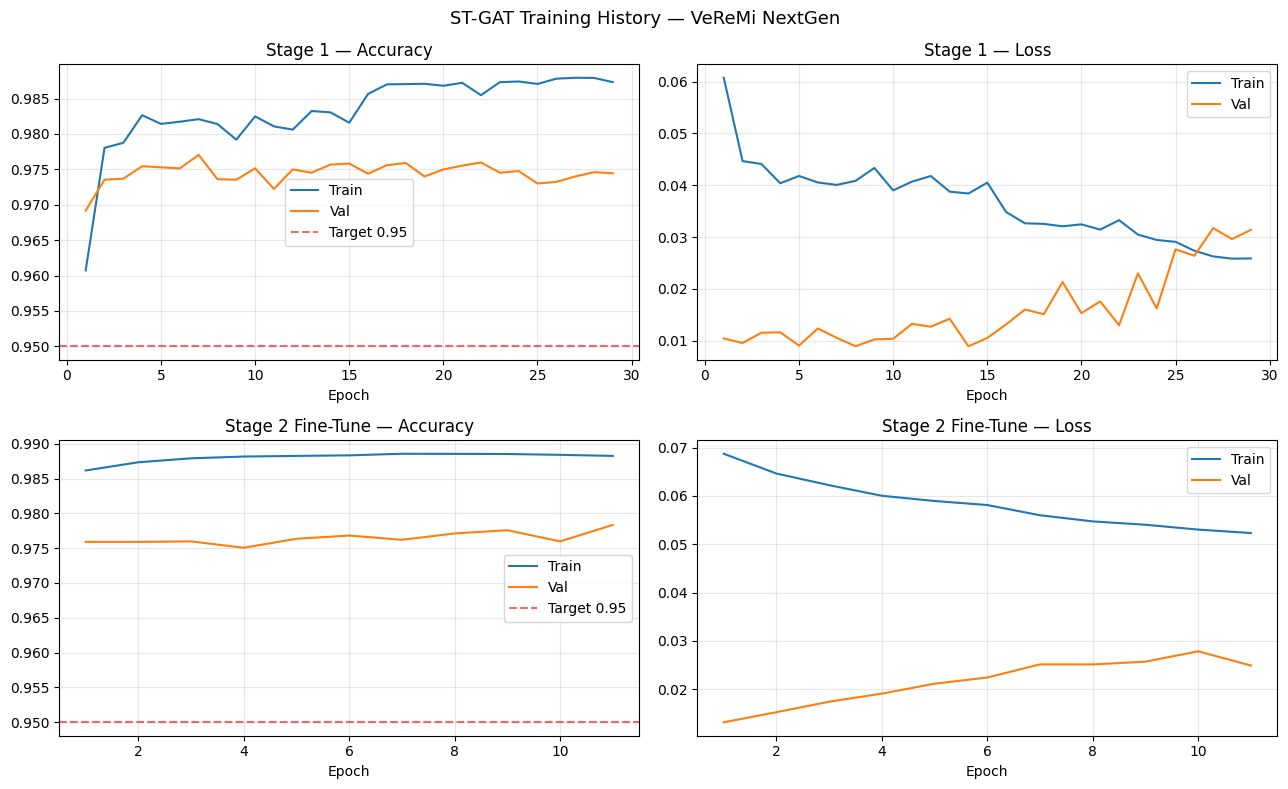

Saved: stgat_training_curves.png


In [14]:
# Cell 13 — Training Curves (Stage 1 + Stage 2)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('ST-GAT Training History — VeReMi NextGen', fontsize=13)

ep1 = range(1, len(history.history['loss']) + 1)
ep2 = range(1, len(ft_history.history['loss']) + 1)

axes[0, 0].plot(ep1, history.history['accuracy'],     label='Train')
axes[0, 0].plot(ep1, history.history['val_accuracy'], label='Val')
axes[0, 0].axhline(TARGET_F1, color='r', ls='--', alpha=0.6, label=f'Target {TARGET_F1}')
axes[0, 0].set_title('Stage 1 — Accuracy')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(ep1, history.history['loss'],     label='Train')
axes[0, 1].plot(ep1, history.history['val_loss'], label='Val')
axes[0, 1].set_title('Stage 1 — Loss')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(ep2, ft_history.history['accuracy'],     label='Train')
axes[1, 0].plot(ep2, ft_history.history['val_accuracy'], label='Val')
axes[1, 0].axhline(TARGET_F1, color='r', ls='--', alpha=0.6, label=f'Target {TARGET_F1}')
axes[1, 0].set_title('Stage 2 Fine-Tune — Accuracy')
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(ep2, ft_history.history['loss'],     label='Train')
axes[1, 1].plot(ep2, ft_history.history['val_loss'], label='Val')
axes[1, 1].set_title('Stage 2 Fine-Tune — Loss')
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/stgat_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: stgat_training_curves.png')


### Stage 2: Targeted Fine-Tune Curves

=== ST-GAT EVALUATION ===

  ST-GAT (optimal-F1 threshold)   [threshold = 0.573]
  Accuracy   0.9838
  Precision  0.9937
  Recall     0.9889   PASS (target >= 0.95)
  F1 Score   0.9913   PASS  (target >= 0.95)
  ROC-AUC    0.9929   PASS  (target >= 0.95)
MCC: 0.8693

  Balanced threshold: 0.452  (min-floor = 0.8771 across normal / Sybil / timeDelay)

  ST-GAT (balanced threshold)   [threshold = 0.452]
  Accuracy   0.9829
  Precision  0.9917
  Recall     0.9900   PASS (target >= 0.95)
  F1 Score   0.9908   PASS  (target >= 0.95)
  ROC-AUC    0.9929   PASS  (target >= 0.95)


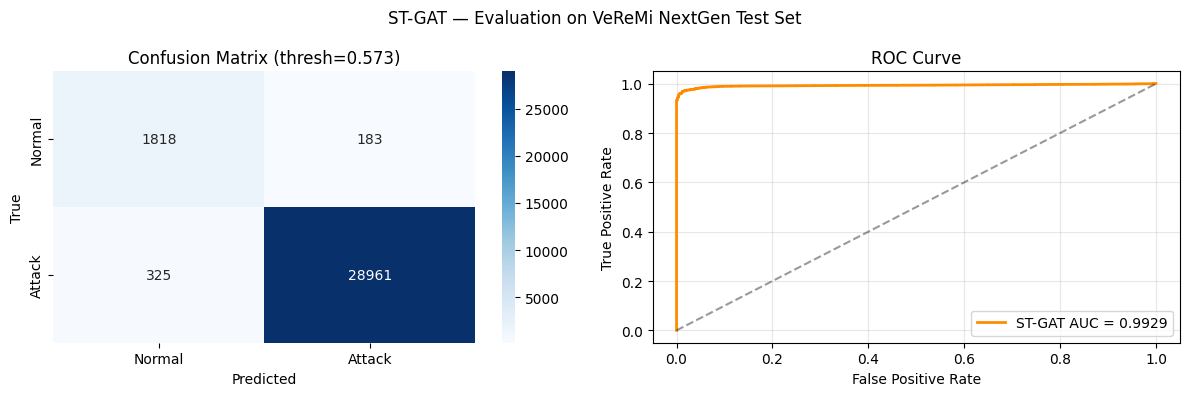

Saved: stgat_evaluation.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Inference: 21.6 ms per sample


In [15]:
# Cell 14 — Evaluate ST-GAT
import time
from sklearn.metrics import matthews_corrcoef
print('=== ST-GAT EVALUATION ===')

scores_stgat = stgat.predict(
    [X_seq_te, X_nbr_te, X_adj_te, X_wagg_te], batch_size=BATCH_SIZE, verbose=0
).flatten()

# -- Optimal-F1 threshold (overall headline metrics) ──────────────────────────
res_stgat = evaluate_model(y_te, scores_stgat, 'ST-GAT (optimal-F1 threshold)')
threshold = res_stgat['threshold']
mcc = matthews_corrcoef(y_te, (scores_stgat >= threshold).astype(int))
print(f"MCC: {mcc:.4f}")

# ── Balanced threshold (maximises min of normal-spec, sybil-rec, td-rec) ─────
bal_t, bal_floor = find_balanced_threshold(y_te, scores_stgat, at_te)
print(f'\n  Balanced threshold: {bal_t:.3f}  '
      f'(min-floor = {bal_floor:.4f} across normal / Sybil / timeDelay)')
res_bal = evaluate_model(y_te, scores_stgat,
                         'ST-GAT (balanced threshold)', threshold=bal_t)

# Use the threshold that gives better overall F1 for the plots
best_res  = res_stgat if res_stgat['f1_score'] >= res_bal['f1_score'] else res_bal
best_thresh = best_res['threshold']

# ── Confusion matrix + ROC ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('ST-GAT — Evaluation on VeReMi NextGen Test Set', fontsize=12)

yp = (scores_stgat >= best_thresh).astype(int)
cm = confusion_matrix(y_te, yp)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0], cmap='Blues',
            xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'])
axes[0].set_title(f'Confusion Matrix (thresh={best_thresh:.3f})')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(y_te, scores_stgat)
auc_val = roc_auc_score(y_te, scores_stgat)
axes[1].plot(fpr, tpr, lw=2, color='darkorange', label=f'ST-GAT AUC = {auc_val:.4f}')
axes[1].plot([0,1],[0,1],'k--',alpha=0.4)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/stgat_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: stgat_evaluation.png')

t0 = time.time()
stgat.predict([X_seq_te[:100], X_nbr_te[:100], X_adj_te[:100], X_wagg_te[:100]], batch_size=100)
print(f"Inference: {(time.time()-t0)*10:.1f} ms per sample")

=== PER-ATTACK-TYPE BREAKDOWN (ST-GAT) ===
  Threshold: 0.573
  Attack type                            F1 / Spec   Recall    Prec       N
--------------------------------------------------------------------------
  accelerationMultiplication                0.9992   0.9985  1.0000   2,001
  constantPositionOffset                    0.9995   0.9990  1.0000   2,001
  dataReplay                                0.9992   0.9985  1.0000   2,001
  dosAttack                                 0.9923   0.9847  1.0000   3,273
  feignedBraking                            0.9995   0.9990  1.0000   2,001
  normal                                    0.9085   [spec]     ---   2,001
  positionMirroring                         0.9998   0.9995  1.0000   2,001
  randomPositionOffset                      0.9995   0.9990  1.0000   2,001
  randomSpeedOffset                         0.9998   0.9995  1.0000   2,001
  reversedHeading                           0.9995   0.9990  1.0000   2,001
  suddenConstantSpeed      

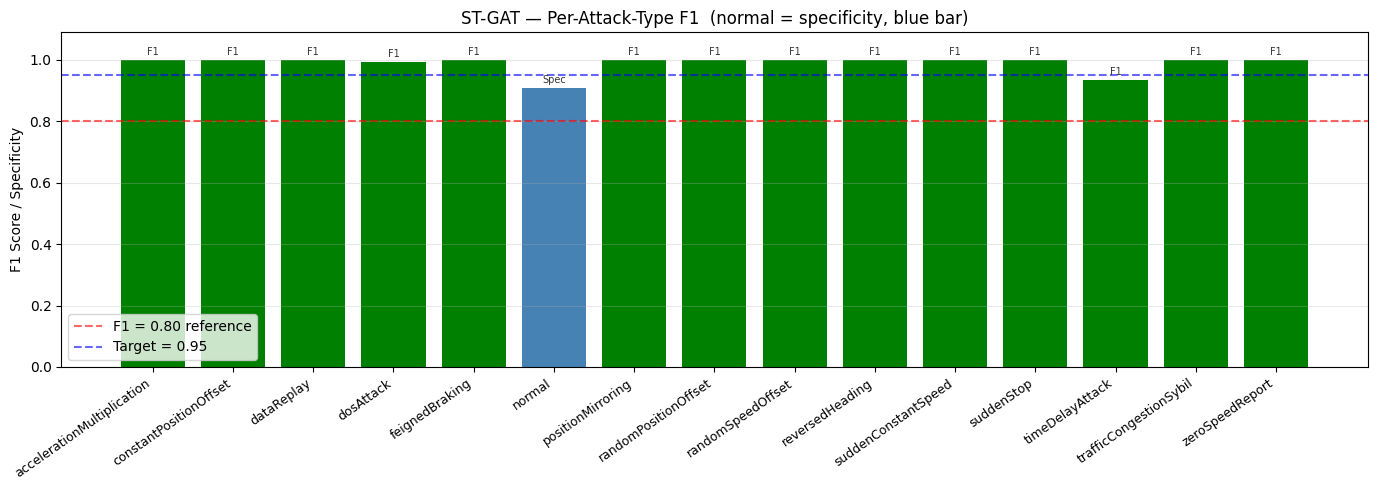

Saved: stgat_per_attack.png

Saved: scaler.pkl  stgat_final.keras  →  /content/drive/MyDrive/V2X_IDS_STGAT
Load for inference:
  scaler = joblib.load("scaler.pkl")
  model  = keras.models.load_model("stgat_final.keras", custom_objects={...})


In [16]:
# Cell 15 — Per-Attack-Type Breakdown
#
# For the 'normal' class all windows have y=0, so sklearn F1 (positive class=1)
# is always zero.  We instead report SPECIFICITY = TN / (TN + FP) — the fraction
# of normal windows the model correctly labels as non-attack.
#
# For all attack types, we report standard F1, Recall, and Precision.

print('=== PER-ATTACK-TYPE BREAKDOWN (ST-GAT) ===')
thresh = best_thresh
pred   = (scores_stgat >= thresh).astype(int)

print(f'  Threshold: {thresh:.3f}')
print(f'  {"Attack type":<37} {"F1 / Spec":>10} {"Recall":>8} {"Prec":>7} {"N":>7}')
print('-' * 74)

results_per_type = {}
for atype in sorted(set(at_te)):
    mask = at_te == atype
    n    = mask.sum()
    if n < 5:
        continue

    if atype == 'normal':
        # Specificity: correct non-attack rate
        spec = ((y_te[mask] == 0) & (pred[mask] == 0)).sum() / n
        results_per_type[atype] = dict(f1=spec, recall=spec, precision=1.0, n=int(n),
                                       metric='spec')
        flag = '' if spec >= 0.90 else '  <-- low specificity'
        print(f'  {atype:<37} {spec:>10.4f} {"[spec]":>8} {"---":>7} {n:>7,}{flag}')
    else:
        f1  = f1_score(y_te[mask], pred[mask], zero_division=0)
        rec = recall_score(y_te[mask], pred[mask], zero_division=0)
        pre = precision_score(y_te[mask], pred[mask], zero_division=0)
        results_per_type[atype] = dict(f1=f1, recall=rec, precision=pre, n=int(n),
                                       metric='f1')
        flag = '' if f1 >= 0.80 else '  <-- low'
        print(f'  {atype:<37} {f1:>10.4f} {rec:>8.4f} {pre:>7.4f} {n:>7,}{flag}')

# Summary bar chart
atypes   = list(results_per_type.keys())
vals     = [results_per_type[a]['f1'] for a in atypes]
labels   = ['Spec' if results_per_type[a]['metric'] == 'spec' else 'F1' for a in atypes]

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['steelblue' if results_per_type[a]['metric'] == 'spec' else
          ('green' if results_per_type[a]['f1'] >= 0.80 else 'salmon')
          for a in atypes]
bars = ax.bar(atypes, vals, color=colors)
ax.axhline(0.80, color='red',  ls='--', alpha=0.6, label='F1 = 0.80 reference')
ax.axhline(TARGET_F1, color='blue', ls='--', alpha=0.6, label=f'Target = {TARGET_F1}')
for bar, lbl in zip(bars, labels):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            lbl, ha='center', va='bottom', fontsize=7, color='#333')
ax.set_xticklabels(atypes, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('F1 Score / Specificity')
ax.set_title('ST-GAT — Per-Attack-Type F1  (normal = specificity, blue bar)')
ax.legend()
ax.set_ylim(0, 1.09)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/stgat_per_attack.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: stgat_per_attack.png')
# ── Save artefacts for inference ─────────────────────────────────────────────
import joblib
joblib.dump(scaler, f'{OUTPUT_DIR}/scaler.pkl')
stgat.save(f'{OUTPUT_DIR}/stgat_final.keras')
print(f'\nSaved: scaler.pkl  stgat_final.keras  →  {OUTPUT_DIR}')
print('Load for inference:')
print('  scaler = joblib.load("scaler.pkl")')
print('  model  = keras.models.load_model("stgat_final.keras", custom_objects={...})')